Author: Dhrubajyoti Ghosh
Assignment: ANN CNN
Version: 1.0
Date: 12 Jul 2026
--------------------------------------------

----------------------

Question (b):
----------------

b)	Use the Bank customer churn dataset from below Kaggle link and create an end-to-end project on Jupyter/Colab to predict the Churn.

https://www.kaggle.com/datasets/santoshd3/bank-customers/data

i.	Download the dataset from above link and load it into your Python environment.

ii.	Perform the EDA and do the visualizations.

iii.	Check the distributions/skewness in the variables and do the transformations if required.

iv.	Check/Treat the outliers and do the feature scaling if required.

v.	Build Deep Learning model using ANN with multiple hidden layers.

vi.	Apply the dropout regularization and early stopping techniques to improve model performance.

vii.	Use the modelCheckpoint also to store the parameters after each epoch.

viii.	Use the KerasTuner to tune to best parameters (No. of hidden layers, optimizers, loss function, activation functions etc.)

ix.	Compare the accuracies of different models and finalize the best model.



----------------------------

In [39]:
#importing basic libraries

import pandas as pd
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [24]:
#Question b: Importing the dataset
df1 = pd.read_csv('Churn Modeling.csv')
df1

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [25]:
#Question b: Checking column Names
df1.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [26]:
#Question b: converting column names to lower case
df1.columns = df1.columns.str.strip().str.lower()
df1.columns

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited'],
      dtype='object')

In [27]:
#Question b: Generating summary about the dataframe
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownumber        10000 non-null  int64  
 1   customerid       10000 non-null  int64  
 2   surname          10000 non-null  object 
 3   creditscore      10000 non-null  int64  
 4   geography        10000 non-null  object 
 5   gender           10000 non-null  object 
 6   age              10000 non-null  int64  
 7   tenure           10000 non-null  int64  
 8   balance          10000 non-null  float64
 9   numofproducts    10000 non-null  int64  
 10  hascrcard        10000 non-null  int64  
 11  isactivemember   10000 non-null  int64  
 12  estimatedsalary  10000 non-null  float64
 13  exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [28]:
#Question b: Though from summary it can be seen there are no null records. Cross verifying the same.
df1.isnull().sum().to_frame(name="null_count").reset_index().rename(columns={"index": "column_name"})

,column_name,null_count
0,rownumber,0
1,customerid,0
2,surname,0
3,creditscore,0
4,geography,0
5,gender,0
6,age,0
7,tenure,0
8,balance,0
9,numofproducts,0


In [29]:
#Question b: Generating Descriptive Statistics. Transposing the columns for better visualization
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
rownumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
customerid,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
creditscore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
numofproducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
hascrcard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
isactivemember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimatedsalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [30]:
#Question b: checking for duplicate rows
int(df1.duplicated().sum())

0

No treatment or null value and duplicate value required.

In [31]:
#Question b: Checking value count of target column to see class imbalancing
df1['exited'].value_counts().reset_index(name='count')

,exited,count
0,0,7963
1,1,2037


In [32]:
#making a copy for the original dataset for future reference

df1_org = df1.copy()

In [33]:
#Question b: Dropping rownumber, customerid and surname information from dataset as they are not required to train the model.
df1 = df1.drop(columns=['rownumber', 'customerid', 'surname'])
df1.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


-------------------------------
Data Visualization
-------------------------------
-------------------------------

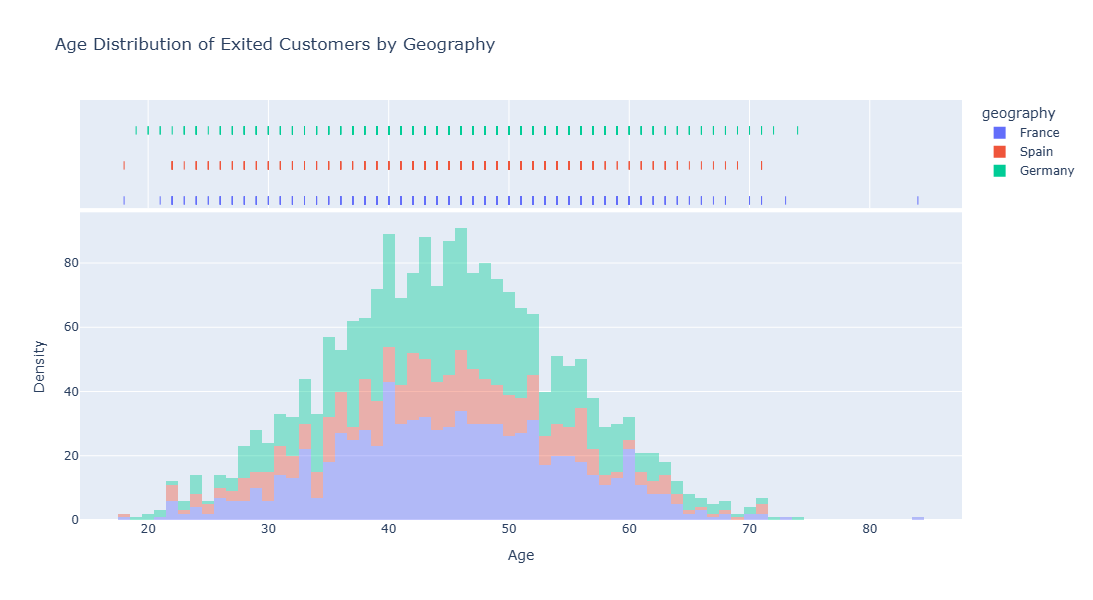

In [43]:
#Question b: Age Distribution of Exited Customers by Geography
exited_df = df1[df1["exited"] == 1]

fig = px.histogram(
    exited_df,
    x="age",
    color="geography",
    histnorm="density",
    opacity=0.4,
    marginal="rug",
    #barmode="overlay",
    title="Age Distribution of Exited Customers by Geography",
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="Density",
    width=800,
    height=600,
)

fig.show()

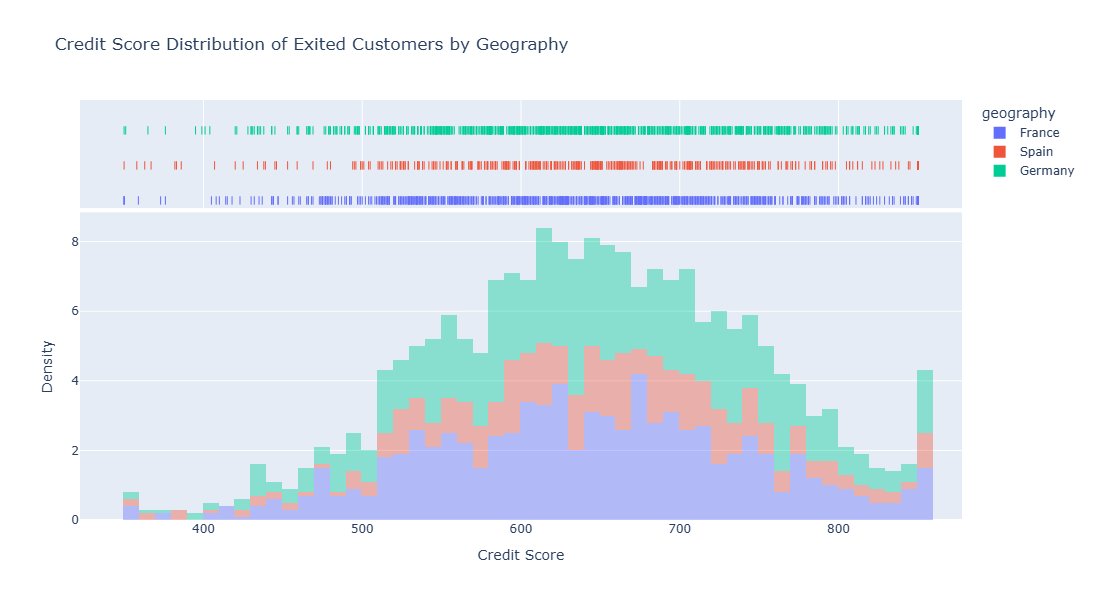

In [46]:
#Question b: Credit Score Distribution of Exited Customers by Geography

fig = px.histogram(
    exited_df,
    x="creditscore",
    color="geography",
    histnorm="density",
    opacity=0.4,
    marginal="rug",
    #barmode="overlay",
    title="Credit Score Distribution of Exited Customers by Geography",
)

fig.update_layout(
    xaxis_title="Credit Score",
    yaxis_title="Density",
    width=800,
    height=600,
)

fig.show()

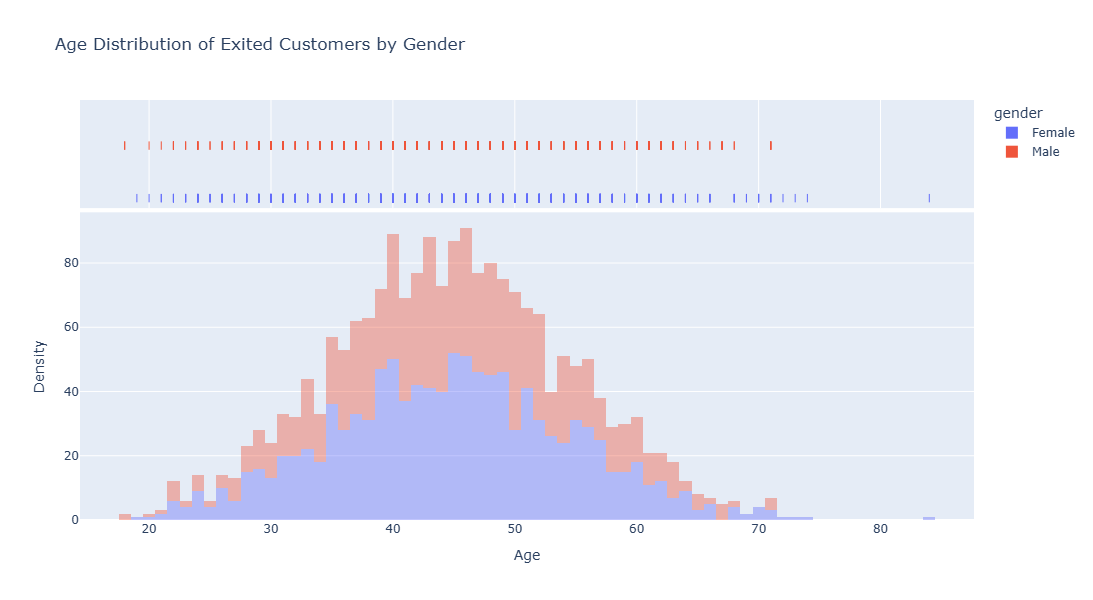

In [47]:
#Question b: Age Distribution of Exited Customers by Gender

fig = px.histogram(
    exited_df,
    x="age",
    color="gender",
    histnorm="density",
    opacity=0.4,
    marginal="rug",
    #barmode="overlay",
    title="Age Distribution of Exited Customers by Gender",
)

fig.update_layout(
    xaxis_title="Age",
    yaxis_title="Density",
    width=800,
    height=600,
)

fig.show()

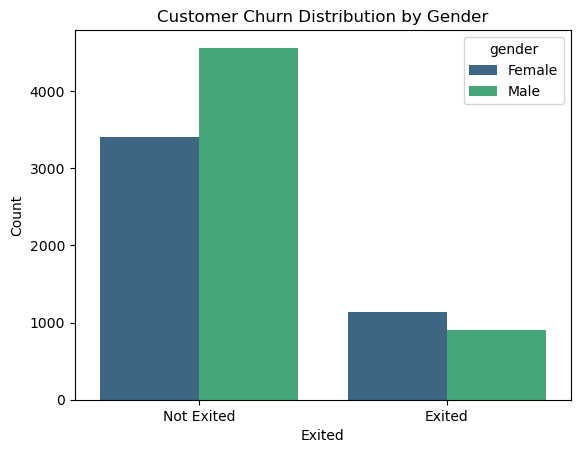

In [55]:
#Question b: Customer churn distribution
sns.countplot(
    x="exited",
    hue="gender",
    data=df1,
    palette="viridis"
)

plt.title("Customer Churn Distribution by Gender")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Exited", "Exited"])

plt.show()

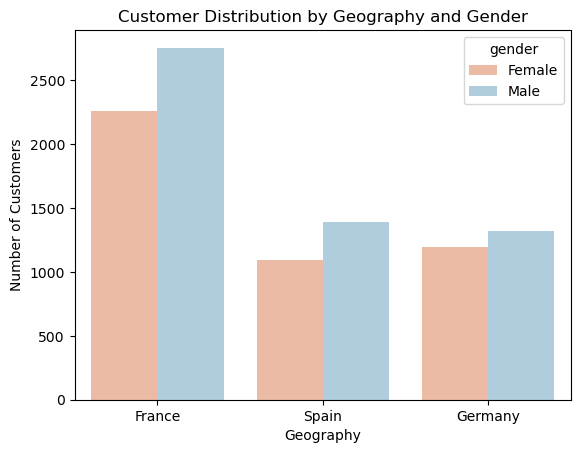

In [60]:
#Question b: Customer churn by geography and gender

sns.countplot(
    x="geography",
    hue="gender",
    data=df1,
    palette="RdBu"
)

plt.title("Customer Distribution by Geography and Gender")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.show()

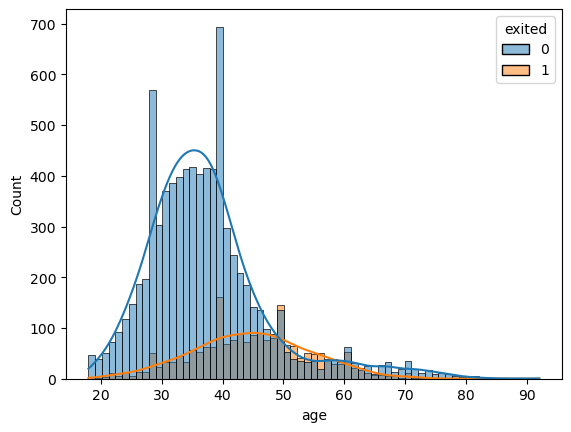

In [62]:
#Question b: Age Distribution by churn status

fig = px.histogram(
    df1,
    x="age",
    color="exited",
    histnorm="density",
    opacity=0.6,
    marginal="rug",
    barmode="overlay",
    nbins=30,
)

fig.update_layout(
    title="Age Distribution by Churn Status",
    xaxis_title="Age of Customers",
    yaxis_title="Density"
)

fig.show()

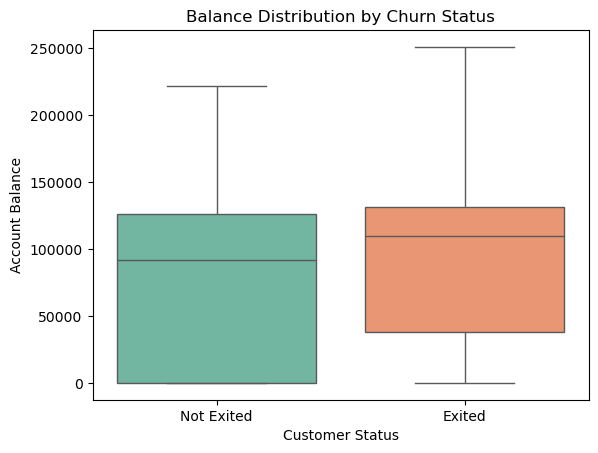

In [68]:
#Question b: Balance Distribution by churn status
sns.boxplot(
    x="exited",
    y="balance",
    data=df1,
    hue="exited",
    palette="Set2",
    legend=False
)
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")
plt.title("Balance Distribution by Churn Status")
plt.xticks([0, 1], ["Not Exited", "Exited"])

plt.show()

--------------------------------
Developing the Model
--------------------------------
--------------------------------

In [71]:
#Question b: dataset check
df1.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [72]:
#Question b: x/y split
#Perfroming train test split
#Independent Variables
x = df1.drop("exited", axis = 1)
#Dependent Variable
y = df1["exited"]

In [73]:
#Question b: checking x
x.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [74]:
#Question b: checking y
y.head()

0    1
1    0
2    1
3    0
4    0
Name: exited, dtype: int64

In [76]:
#Question b: Perfroming train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 3)

In [78]:
#Question b: Perfroming Ordinal Encoding on categorical data
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[['geography','gender']] = oe.fit_transform(x_train[['geography','gender']])
x_test[['geography','gender']] = oe.transform(x_test[['geography','gender']])

In [79]:
x_train.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
2377,549,0.0,1.0,50,9,94748.76,2,0,1,13608.18
6515,803,0.0,0.0,65,2,151659.52,2,0,1,6930.17
292,583,0.0,1.0,27,7,0.00,2,1,0,51285.49
2859,551,2.0,1.0,32,4,0.00,2,1,0,53420.53
1912,687,1.0,0.0,29,4,78939.15,1,1,0,122134.56


In [80]:
#Question b: Creating a function to check positive and negative skewness
def check_skew_dirn(val):
    if val > 0:
        return "Positive/Right"
    elif val < 0:
        return "Negative/Left"
    else:
        return "No Skew"

In [81]:
#Question b: Creating a function to categorize columns as per skewness

def categorize_skew(val):
    abs_skew = abs(val)
    
    if abs_skew < 0.5:
        lvl = "Lightly skewed"
    elif abs_skew < 1:
        lvl = "Moderately skewed"
    else:
        lvl = "Highly skewed"
    
    return lvl

In [82]:
#Question b: Checking Skewness
df_skewness = x_train.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness

,column_name,skewness
0,creditscore,-0.063516
1,geography,0.502852
2,gender,-0.177800
3,age,1.042166
4,tenure,0.014766
5,balance,-0.132765
6,numofproducts,0.733997
7,hascrcard,-0.895356
8,isactivemember,-0.051761
9,estimatedsalary,0.012241


In [83]:
#Question b: Checking skewness of the columns

df_skewness_cpy = df_skewness.copy()
df_skewness_cpy["skew_category"] = df_skewness_cpy["skewness"].apply(categorize_skew)
df_skewness_cpy

,column_name,skewness,skew_category
0,creditscore,-0.063516,Lightly skewed
1,geography,0.502852,Moderately skewed
2,gender,-0.177800,Lightly skewed
3,age,1.042166,Highly skewed
4,tenure,0.014766,Lightly skewed
5,balance,-0.132765,Lightly skewed
6,numofproducts,0.733997,Moderately skewed
7,hascrcard,-0.895356,Moderately skewed
8,isactivemember,-0.051761,Lightly skewed
9,estimatedsalary,0.012241,Lightly skewed


In [84]:
#Question b: Checking skewness direction of the columns
df_skewness_cpy["skew_direction"] = df_skewness_cpy["skewness"].apply(check_skew_dirn)
df_skewness_cpy

,column_name,skewness,skew_category,skew_direction
0,creditscore,-0.063516,Lightly skewed,Negative/Left
1,geography,0.502852,Moderately skewed,Positive/Right
2,gender,-0.177800,Lightly skewed,Negative/Left
3,age,1.042166,Highly skewed,Positive/Right
4,tenure,0.014766,Lightly skewed,Positive/Right
5,balance,-0.132765,Lightly skewed,Negative/Left
6,numofproducts,0.733997,Moderately skewed,Positive/Right
7,hascrcard,-0.895356,Moderately skewed,Negative/Left
8,isactivemember,-0.051761,Lightly skewed,Negative/Left
9,estimatedsalary,0.012241,Lightly skewed,Positive/Right


In [85]:
#Question b: Identifying highly and moderately skewed columns and converting it into a list
skewed_cols = df_skewness_cpy[
    df_skewness_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols

['geography', 'age', 'numofproducts', 'hascrcard']

In [86]:
#Question b: Function to identify & clip outliers
#Here, values below lower will be replaced with lower limit will be replaced with Lower limit value 
#and values above the upper limit will be replaced with upper limit value and values in between shall remain unchanged

#Using Capping & Flooring method

def manage_outliers(col_df, col_name):
    lower = col_df[col_name].quantile(0.01)
    upper = col_df[col_name].quantile(0.99)
    col_df[col_name] = col_df[col_name].clip(lower,upper)
    return col_df

In [87]:
#Question b: Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train.columns:
    x_train = manage_outliers(x_train, col)

In [88]:
#Question b: new value of training dataset after outlier treatment
x_train.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
2377,549,0.0,1.0,50,9,94748.76,2,0,1,13608.18
6515,803,0.0,0.0,65,2,151659.52,2,0,1,6930.17
292,583,0.0,1.0,27,7,0.00,2,1,0,51285.49
2859,551,2.0,1.0,32,4,0.00,2,1,0,53420.53
1912,687,1.0,0.0,29,4,78939.15,1,1,0,122134.56


In [90]:
#Question b: Treating skewness using PowerTransformer - Training Dataset
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="yeo-johnson")
x_train[skewed_cols] = pt.fit_transform(x_train[skewed_cols]) #for power transform
x_test[skewed_cols] = pt.transform(x_test[skewed_cols])

In [91]:
#Question b: Performing Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

---------------------------------
**Simple ANN Model**

---------------------------------

In [93]:
!pip install tensorflow

  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 7.6 MB/s eta 0:00:47
   ---------------------------------------- 1.8/351.2 MB 5.4 MB/s eta 0:01:06
   ---------------------------------------- 2.9/351.2 MB 5.9 MB/s eta 0:00:59
   ---------------------------------------- 3.7/351.2 MB 4.8 MB/s eta 0:01:13
   ---------------------------------------- 3.9/351.2 MB 4.1 MB/s eta 0:01:25
   ---------------------------------------- 4.2/351.2 MB 3.5 MB/s eta 0:01:41
   ---------------------------------------- 4.2/351.2 MB 3.5 MB/s eta 0:01:41
    --------------------------------------- 4.5/351.2 MB 3.0 MB/s eta 0:01:54
    --------------------------------------- 4.7/351.2 MB 2.8 MB/s eta 0:02:05
    --------------------------------------- 5.0/351.2 MB 2.6 MB/s eta 0:02:14
    --------------------------------------- 5.2/351.2 MB 2.5 MB/s eta 0:

In [138]:
#Question b: importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

In [108]:
#Question b: building a simple model
model_simple = keras.Sequential()
model_simple.add(Dense(15, input_dim = 10, activation = 'relu', kernel_initializer = 'he_normal'))
model_simple.add(Dense(15, activation = 'relu', kernel_initializer = 'he_normal'))
#model_simple.add(Dense(15, activation = 'relu', kernel_initializer = 'he_normal'))
model_simple.add(Dense(1, activation = 'sigmoid'))

#use below code to avoid this warning
model_simple = Sequential()

model_simple.add(Input(shape=(10,)))

model_simple.add(Dense(15, activation='relu', kernel_initializer='he_normal'))

model_simple.add(Dense(15, activation='relu', kernel_initializer='he_normal'))

model_simple.add(Dense(1, activation='sigmoid'))

In [109]:
#Question b: checking summary
model_simple.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421 (1.64 KB)

 Trainable params: 421 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

In [110]:
#Question b: 
model_simple.compile(loss = 'binary_crossentropy',optimizer = 'adam', metrics = ['accuracy'])

#Question b: training the model
history_simple = model_simple.fit(x_train_scaled, y_train, epochs = 10, validation_split = 0.2)

In [111]:
#Question b: training the model - with 15 epochs as loss is reducing and accuracy is increasing
#with 10 epochs: accuracy -> 0.8555 
#with 15 epochs: accuracy -> 0.8592 
#30 epochs: accuracy -> 0.8628 
#Added another hidden layer
#accuracy after 30 epochs: 0.8530 
#removed the added layer and after 30 epochs accuracy is 0.8555 still comparable to previous values

history_simple = model_simple.fit(x_train_scaled, y_train, epochs = 30, validation_split = 0.2)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7960 - loss: 0.5044 - val_accuracy: 0.8020 - val_loss: 0.4803
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7978 - loss: 0.4551 - val_accuracy: 0.7987 - val_loss: 0.4558
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8055 - loss: 0.4367 - val_accuracy: 0.8047 - val_loss: 0.4453
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8133 - loss: 0.4264 - val_accuracy: 0.8067 - val_loss: 0.4397
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8195 - loss: 0.4198 - val_accuracy: 0.8127 - val_loss: 0.4346
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8203 - loss: 0.4138 - val_accuracy: 0.8140 - val_loss: 0.4294
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8248 - loss: 0.4091 - val_accuracy: 0.8173 - val_loss: 0.4250
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8270 - loss: 0.4046 - val_accuracy: 0.

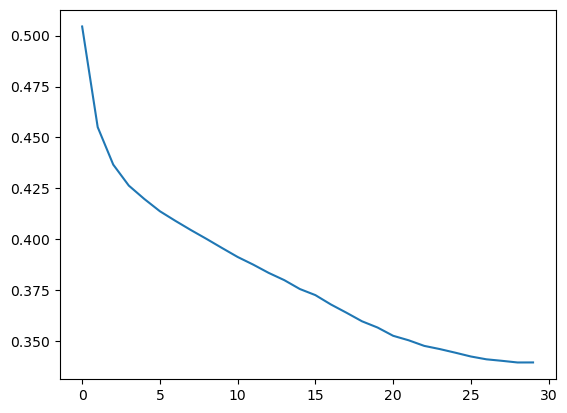

In [113]:
#Question b: Accuracy is increasing but not tho that extent.
plt.plot(history_simple.history['loss'])

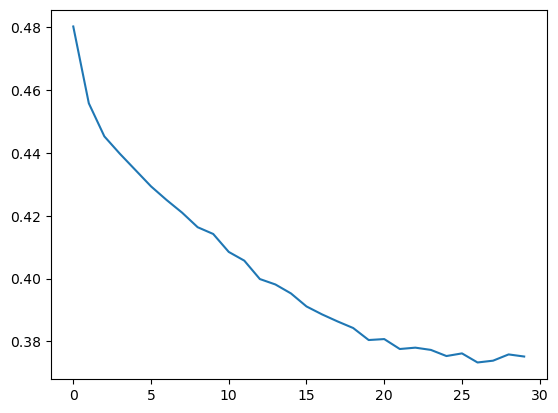

In [114]:
#Question b: Accuracy is increasing but not tho that extent.
plt.plot(history_simple.history['val_loss'])

In [134]:
#Defining a function that takes predicted value and actual value as input and Classification Metrics Values
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def classification_metrics_all(
    y_train_actual, y_train_predicted,
    y_test_actual, y_test_predicted,
    overfit_threshold
):

    # Accuracy
    train_acc = accuracy_score(y_train_actual, y_train_predicted)
    test_acc = accuracy_score(y_test_actual, y_test_predicted)

    # Precision (per class)
    train_precision = precision_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_precision = precision_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Recall (per class)
    train_recall = recall_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_recall = recall_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # F1-score (per class)
    train_f1 = f1_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_f1 = f1_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Confusion Matrix
    train_cm = confusion_matrix(y_train_actual, y_train_predicted)
    test_cm = confusion_matrix(y_test_actual, y_test_predicted)

    # Overfitting check (based on accuracy gap)
    if (train_acc - test_acc) > overfit_threshold:
        overfit_flag = 'Y'
    else:
        overfit_flag = 'N'

    metrics_df = pd.DataFrame({
            'Metric': [
                'Accuracy',
                'Precision Class 0',
                'Precision Class 1',
                'Recall Class 0',
                'Recall Class 1',
                'F1 Class 0',
                'F1 Class 1',
                'Overfit Flag'
            ],
            'Train': [
                train_acc,
                train_precision[0],
                train_precision[1],
                train_recall[0],
                train_recall[1],
                train_f1[0],
                train_f1[1],
                overfit_flag
            ],
            'Test': [
                test_acc,
                test_precision[0],
                test_precision[1],
                test_recall[0],
                test_recall[1],
                test_f1[0],
                test_f1[1],
                overfit_flag
            ]
        })

    return metrics_df

In [125]:
#Question b:predicting output
# predictions
y_train_pred_simple = model_simple.predict(x_train_scaled)
y_train_pred_simple = (y_train_pred_simple >= 0.5).astype(int)
y_test_pred_simple = model_simple.predict(x_test_scaled)
y_test_pred_simple = (y_test_pred_simple >= 0.5).astype(int)

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [126]:
y_train_pred_simple

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(7500, 1))

In [127]:
y_test_pred_simple

array([[0],
       [0],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(2500, 1))

In [135]:
#Question b: checking performance
perf_simple = classification_metrics_all(y_train, y_train_pred_simple, y_test, y_test_pred_simple, 0.5)

In [136]:
perf_simple

,Metric,Train,Test
0,Accuracy,0.855733,0.846
1,Precision Class 0,0.865979,0.855996
2,Precision Class 1,0.770756,0.758755
3,Recall Class 0,0.969069,0.968718
4,Recall Class 1,0.40948,0.376448
5,F1 Class 0,0.914628,0.908876
6,F1 Class 1,0.534824,0.503226
7,Overfit Flag,N,N


In [139]:
#Question b: model using dropout regularization and early stopping and model checkpoint

model_ver2 = Sequential()

model_ver2.add(Input(shape=(10,)))

model_ver2.add(Dense(60, activation='relu', kernel_initializer='he_normal'))
model_ver2.add(Dropout(0.3))

model_ver2.add(Dense(30, activation='relu', kernel_initializer='he_normal'))
model_ver2.add(Dropout(0.3))

model_ver2.add(Dense(15, activation='relu', kernel_initializer='he_normal'))
model_ver2.add(Dropout(0.3))

model_ver2.add(Dense(1, activation='sigmoid'))

In [140]:
#Question b: summary
model_ver2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 60)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,971 (11.61 KB)

 Trainable params: 2,971 (11.61 KB)

 Non-trainable params: 0 (0.00 B)

In [141]:
#Question b: 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [142]:
#Question b: adding model checkpoing
checkpoint_ver2 = ModelCheckpoint(
    filepath='weights_epoch_{epoch:02d}.weights.h5',
    save_weights_only=True,
    save_best_only=False,
    verbose=1
)

In [143]:
#Question b: early stopping
early_stop_ver2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [146]:
#Question b: compiling the model
model_ver2.compile(loss = 'binary_crossentropy',optimizer = 'adam', metrics = ['accuracy'])

In [147]:
#Question b: training the model
history_ver2 = model_ver2.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_ver2, checkpoint_ver2]
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7393 - loss: 0.5662
Epoch 1: saving model to weights_epoch_01.weights.h5

Epoch 1: finished saving model to weights_epoch_01.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7393 - loss: 0.5662 - val_accuracy: 0.7944 - val_loss: 0.4715
Epoch 2/100
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 0.4824
Epoch 2: saving model to weights_epoch_02.weights.h5

Epoch 2: finished saving model to weights_epoch_02.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7920 - loss: 0.4823 - val_accuracy: 0.7928 - val_loss: 0.4480
Epoch 3/100
230/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8005 - loss: 0.4670
Epoch 3: saving model to weights_epoch_03.weights.h5

Epoch 3: finished saving model to weights_epoch_03.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8005 - loss: 0.4666 - val_accuracy: 0.7944 - val_loss: 0.4418
Epoch 4/100
230/235 ━━━━━━━━━━━━━━━━━━━━

In [148]:
#Question b:predicting output
# predictions
y_train_pred_ver2 = model_ver2.predict(x_train_scaled)
y_train_pred_ver2 = (y_train_pred_ver2 >= 0.5).astype(int)
y_test_pred_ver2 = model_ver2.predict(x_test_scaled)
y_test_pred_ver2 = (y_test_pred_ver2 >= 0.5).astype(int)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [186]:
#Question b: checking performance
perf_ver2 = classification_metrics_all(y_train, y_train_pred_ver2, y_test, y_test_pred_ver2, 0.5)
perf_ver2

,Metric,Train,Test
0,Accuracy,0.860533,0.854
1,Precision Class 0,0.866479,0.857902
2,Precision Class 1,0.808344,0.817427
3,Recall Class 0,0.975422,0.9778
4,Recall Class 1,0.408163,0.380309
5,F1 Class 0,0.917728,0.913935
6,F1 Class 1,0.542432,0.519104
7,Overfit Flag,N,N


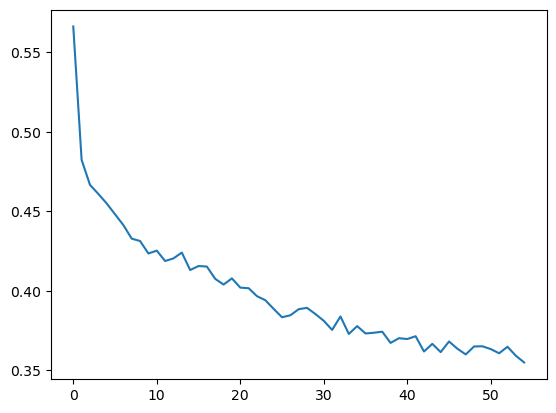

In [150]:
#Question b: Accuracy is increasing but not tho that extent.
plt.plot(history_ver2.history['loss'])

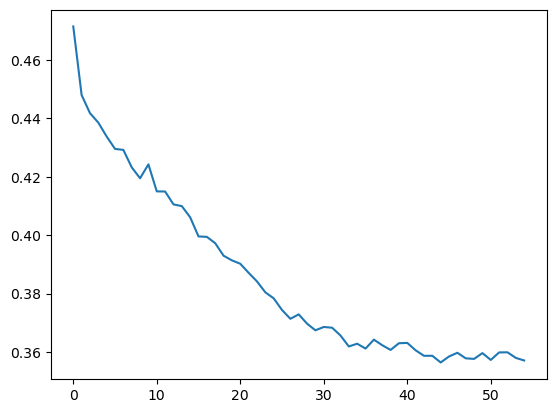

In [151]:
#Question b: Accuracy is increasing but not tho that extent.
plt.plot(history_ver2.history['val_loss'])

--------------------------
**Using Keras Tuner**

-------------------------

In [172]:
#Question b: Creating a model for Keras tuner
def build_ann_keras_model(hyperparameter):
    #initializing model
    model = keras.Sequential()
    #tuning number of layers
    for i in range(hyperparameter.Int('num_layers',min_value = 1,max_value = 3)):
        model.add(Dense(units = hyperparameter.Int(f'units_{i}', min_value = 32, max_value = 512, step = 32), 
                               activation = 'relu', 
                               kernel_initializer='he_normal'))
    #output layer for classification
    model.add(Dense(1, activation = 'sigmoid'))
    #tune the optimizer type
    optimizer = optimizer = hyperparameter.Choice(
        'optimizer',
        values=['adam', 'sgd', 'rmsprop']
    )

    model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
    return model

In [162]:
!pip install keras_tuner

In [176]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   ------- -------------------------------- 1.0/5.5 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 1.6/5.5 MB 3.2 MB/s eta 0:00:02
   ------------- -------------------------- 1.8/5.5 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 2.6/5.5 MB 2.8 MB/s eta 0:00:02
   -------------------- ------------------- 2.9/5.5 MB 2.6 MB/s eta 0:00:02
   ------------------------ --------------- 3.4/5.5 MB 2.5 MB/s eta 0:00:01
   -------------------------- ------------- 3.7/5.5 MB 2.4 MB/s eta 0:00:01
   ---------------------------- ----------- 3.9/5.5 MB 2.4 MB/s eta 0:00:01
   -------------------------------- ------- 4.5/5.5 MB 2.3 MB/s eta 0:00:01
   ---------------------------------- ----- 4.7/5.5 MB 2.2 MB/s eta 0:00:01
   -------------------------------------- - 5.2/5.5 MB 2.2 MB/s eta 0:00:01
   -----------------------

In [177]:
import tensorboard

In [158]:
import keras_tuner as kt
from keras_tuner import RandomSearch

In [173]:
#Question b: Set up Tuner using Random Search
tuner_keras = RandomSearch(build_ann_keras_model, 
                            objective = 'val_accuracy', 
                            max_trials = 10, 
                            executions_per_trial = 2,
                            directory = 'tuner_dir',
                            project_name= 'binary_classification' #'boston_housing'
                           )

In [174]:
#Question b: Early stopping to Keras Tuner
early_stop_keras = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [178]:
#Question b: Search for best parameters
tuner_keras.search(x_train_scaled, y_train, epochs = 100, validation_data=(x_test_scaled, y_test), batch_size = 32, callbacks=[early_stop_keras])

Trial 10 Complete [00h 03m 20s]
val_accuracy: 0.8537999987602234

Best val_accuracy So Far: 0.8594000041484833
Total elapsed time: 00h 15m 44s


In [180]:
#Question b: get the best model
best_model_keras = tuner_keras.get_best_models(num_models=1)[0]

C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 



In [188]:
#Question b: to avoid this warning ('Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. ')
#, it is better to recompile the model before fitting

best_model_keras = tuner_keras.get_best_models(num_models=1)[0]

best_model_keras.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#best_model_keras.fit(x_train_scaled, y_train, epochs=10)
history_keras = best_model_keras.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_test_scaled, y_test),
    epochs=100,
    callbacks=[early_stop_keras]
)

Epoch 1/100


C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 



235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8652 - loss: 0.3189 - val_accuracy: 0.8548 - val_loss: 0.3571
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8639 - loss: 0.3189 - val_accuracy: 0.8584 - val_loss: 0.3562
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8659 - loss: 0.3182 - val_accuracy: 0.8552 - val_loss: 0.3559
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8665 - loss: 0.3167 - val_accuracy: 0.8556 - val_loss: 0.3572
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8651 - loss: 0.3167 - val_accuracy: 0.8588 - val_loss: 0.3566
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8656 - loss: 0.3170 - val_accuracy: 0.8548 - val_loss: 0.3583
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8648 - loss: 0.3159 - val_accuracy: 0.8544 - val_loss: 0.3587
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8683 - loss: 0.3153 - val_accuracy: 0.8572

In [181]:
#Question b: get the best hyperparameters
best_hp = tuner_keras.get_best_hyperparameters(num_trials=1)[0]

In [183]:
#Question b: display the best hyperparameters
print("Number of hidden layers:", best_hp.get("num_layers"))

for i in range(best_hp.get("num_layers")):
    print(f"Units in layer {i+1}:", best_hp.get(f"units_{i}"))

print("Optimizer:", best_hp.get("optimizer"))

Number of hidden layers: 1
Units in layer 1: 96
Optimizer: adam


In [189]:
#Question b: predictions
y_train_pred_keras = best_model_keras.predict(x_train_scaled)
y_train_pred_keras = (y_train_pred_keras >= 0.5).astype(int)
y_test_pred_keras = best_model_keras.predict(x_test_scaled)
y_test_pred_keras = (y_test_pred_keras >= 0.5).astype(int)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [190]:
#Question b: checking performance
perf_keras = classification_metrics_all(y_train, y_train_pred_keras, y_test, y_test_pred_keras, 0.5)
perf_keras

,Metric,Train,Test
0,Accuracy,0.868267,0.8576
1,Precision Class 0,0.881786,0.869882
2,Precision Class 1,0.776275,0.768212
3,Recall Class 0,0.964053,0.964682
4,Recall Class 1,0.491113,0.447876
5,F1 Class 0,0.921086,0.914833
6,F1 Class 1,0.601613,0.565854
7,Overfit Flag,N,N


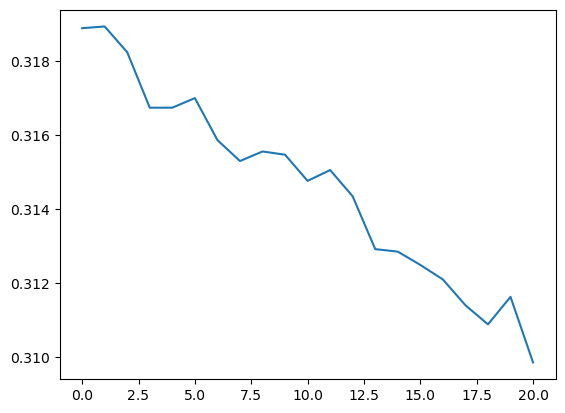

In [191]:
plt.plot(history_keras.history['loss'])

By comparing the accuracies, it can be observed, best_model_keras has relatively better accuracy. 
Hence, proceeding with this model

In [193]:
import pickle

In [194]:
#Question b: generating pickle files
pickle.dump(oe, open("oe_ann_bank_churn.pkl", "wb")) 
pickle.dump(pt, open("powertransformer_ann_bank_churn.pkl", "wb")) 
pickle.dump(scaler, open("scaler_ann_bank_churn.pkl", "wb"))
pickle.dump(best_model_keras, open("best_model_keras_ann_bank_churn.pkl", "wb")) #ANN Model

-------------------------------------------------------
**Question c**

-------------------------------------------------------

c)	Use the following Accident detection Dataset link and create an end-to-end project to predict Accident has happened or not.

https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage/data

i.	Import the dataset and perform the EDA and do the visualizations.

ii.	Create model from scratch using your own number of filters, loss functions, no. of epochs and check the accuracy.

iii.	Now use the pretrained model to check if accuracy gets improved.

iv.	After that, go for data augmentation and further check if accuracy has improved.

v.	Compare the training and testing accuracy with all these 3 approaches and suggest the best model.




------------------------